# ML Models Interpretability

Centralized interpretability for every classical ML notebook in `notebooks/ml-models`:

- Ridge (`model_ridge.ipynb`)
- Random Forest (`model_random_forest.ipynb`)
- SVM (`model_svm.ipynb`)
- XGBoost (`model_xgboost.ipynb`)
- Weighted Ensemble (`model_weighted_ensemble.ipynb`)

All generated plots and tables live in this folder under `outcome/`.


## Policy

The notebook keeps the source notebook for each model explicit. For the single-model explanations, it uses the same model family and hyperparameters defined in those notebooks, but fits local interpretability copies on the weighted-ensemble feature-selected top descriptors. That keeps all SHAP plots comparable and runnable.

If a local interpretability copy already exists in `outcome/models`, it is loaded instead of refitted. The weighted ensemble itself is imported from its saved notebook artifact and explained as a weighted sum of its active components.


In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'interpratability':
    NOTEBOOK_DIR = Path('notebooks/ml-models/interpratability').resolve()

ML_MODELS_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = ML_MODELS_DIR.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.modeling import load_feature_selected_arrays

OUTCOME_DIR = NOTEBOOK_DIR / 'outcome'
FIGURES_DIR = OUTCOME_DIR / 'figures'
TABLES_DIR = OUTCOME_DIR / 'tables'
INTERP_MODEL_DIR = OUTCOME_DIR / 'models'
for directory in (FIGURES_DIR, TABLES_DIR, INTERP_MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
FEATURE_BUDGET = 100
BACKGROUND_SIZE = 40
EXPLAIN_SIZE = 160
SVM_EXPLAIN_SIZE = 8
MAX_DISPLAY = 20

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'axes.grid': True, 'grid.alpha': 0.25})


## Source Notebooks And Data

The feature space is the ranked feature-selection table already used by the weighted ensemble. This avoids explaining thousands of mostly sparse descriptors and makes the beeswarm plots readable.


In [2]:
MODEL_NOTEBOOKS = {
    'ridge': ML_MODELS_DIR / 'model_ridge.ipynb',
    'random_forest': ML_MODELS_DIR / 'model_random_forest.ipynb',
    'svm': ML_MODELS_DIR / 'model_svm.ipynb',
    'xgboost': ML_MODELS_DIR / 'model_xgboost.ipynb',
    'weighted_ensemble': ML_MODELS_DIR / 'model_weighted_ensemble.ipynb',
}

data_dir = PROJECT_ROOT / 'data/feature_selection/_200'
feature_dir = PROJECT_ROOT / 'data/feature_selection/_200'

(
    X_train_all,
    X_valid_all,
    X_test_all,
    y_train,
    y_valid,
    y_test,
    feature_names_all,
    preprocessor,
) = load_feature_selected_arrays(target_data_dir=data_dir, feature_dir=feature_dir)

feature_budget = min(FEATURE_BUDGET, X_train_all.shape[1])
X_train = X_train_all[:, :feature_budget].astype(np.float32)
X_valid = X_valid_all[:, :feature_budget].astype(np.float32)
X_test = X_test_all[:, :feature_budget].astype(np.float32)
feature_names = np.asarray([str(name) for name in feature_names_all[:feature_budget]])
clean_feature_names = np.asarray([name.replace('num__', '').replace('cat__', '') for name in feature_names])

source_table = pd.DataFrame([
    {
        'model': name,
        'source_notebook': str(path.relative_to(PROJECT_ROOT)),
        'interpretability_feature_budget': feature_budget,
    }
    for name, path in MODEL_NOTEBOOKS.items()
])
source_table.to_csv(TABLES_DIR / 'model_sources.csv', index=False)
source_table


,model,source_notebook,interpretability_feature_budget
0,ridge,notebooks/ml-models/model_ridge.ipynb,100
1,random_forest,notebooks/ml-models/model_random_forest.ipynb,100
2,svm,notebooks/ml-models/model_svm.ipynb,100
3,xgboost,notebooks/ml-models/model_xgboost.ipynb,100
4,weighted_ensemble,notebooks/ml-models/model_weighted_ensemble.ipynb,100


## Import / Fit Interpretability Models

These local models mirror the model definitions from the source notebooks and are saved in `interpratability/outcome/models` so repeated runs do not retrain them.


In [3]:
def regression_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def local_model_path(name):
    return INTERP_MODEL_DIR / f'{name}_interpretability_model.pkl'


def load_or_fit(name, factory, fit_fn=None):
    path = local_model_path(name)
    if path.exists():
        return joblib.load(path), 'local_interpretability_artifact'
    model = factory()
    if fit_fn is None:
        model.fit(X_train, y_train)
    else:
        fit_fn(model)
    joblib.dump(model, path)
    return model, 'fit_from_source_notebook_config'


def fit_xgboost(model):
    try:
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    except Exception as exc:
        warnings.warn(f'XGBoost CUDA failed; retrying on CPU. Details: {exc}')
        model.set_params(device='cpu')
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)


MODEL_FACTORIES = {
    'ridge': lambda: RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=None),
    'random_forest': lambda: RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'svm': lambda: SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
    'xgboost': lambda: xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda',
        random_state=RANDOM_STATE,
    ),
}

models = {}
model_rows = []
for name, factory in MODEL_FACTORIES.items():
    print(f'Loading/fitting {name}...')
    fit_fn = fit_xgboost if name == 'xgboost' else None
    model, source = load_or_fit(name, factory, fit_fn=fit_fn)
    models[name] = model
    model_rows.append({
        'model': name,
        'source': source,
        'source_notebook': str(MODEL_NOTEBOOKS[name].relative_to(PROJECT_ROOT)),
        'local_artifact': str(local_model_path(name).relative_to(PROJECT_ROOT)),
    })

model_imports = pd.DataFrame(model_rows)
model_imports.to_csv(TABLES_DIR / 'model_imports.csv', index=False)
model_imports


Loading/fitting ridge...
Loading/fitting random_forest...
Loading/fitting svm...
Loading/fitting xgboost...


,model,source,source_notebook,local_artifact
0,ridge,local_interpretability_artifact,notebooks/ml-models/model_ridge.ipynb,notebooks/ml-models/interpratability/outcome/m...
1,random_forest,local_interpretability_artifact,notebooks/ml-models/model_random_forest.ipynb,notebooks/ml-models/interpratability/outcome/m...
2,svm,local_interpretability_artifact,notebooks/ml-models/model_svm.ipynb,notebooks/ml-models/interpratability/outcome/m...
3,xgboost,local_interpretability_artifact,notebooks/ml-models/model_xgboost.ipynb,notebooks/ml-models/interpratability/outcome/m...


## Weighted Ensemble Import

The weighted ensemble is imported from `model_weighted_ensemble.ipynb` output. It already contains fitted component models, optimized weights, and the selected feature names.


In [4]:
weighted_ensemble_path = ML_MODELS_DIR / 'outcome' / 'models' / 'weighted_ensemble_model.joblib'
if not weighted_ensemble_path.exists():
    raise FileNotFoundError(f'Missing weighted ensemble artifact: {weighted_ensemble_path}')
weighted_ensemble = joblib.load(weighted_ensemble_path)

ensemble_weights = pd.DataFrame([
    {'component': name, 'weight': float(weight)}
    for name, weight in weighted_ensemble['weights'].items()
]).sort_values('weight', ascending=False)
ensemble_weights.to_csv(TABLES_DIR / 'weighted_ensemble_weights.csv', index=False)
ensemble_weights


,component,weight
5,xgboost,6.346948e-01
3,extra_trees,3.653052e-01
2,random_forest,9.541735e-17
4,hist_gradient_boosting,9.467469e-17
1,elastic_net,6.120653e-18
0,ridge,5.338335e-19


## Prediction Check

Metrics are computed on the held-out test rows for the same feature-selected matrix used by the explanations.


In [5]:
def weighted_ensemble_predict(bundle, X):
    pred = np.zeros(X.shape[0], dtype=float)
    for name, weight in bundle['weights'].items():
        if abs(float(weight)) <= 1e-12:
            continue
        pred += float(weight) * np.asarray(bundle['models'][name].predict(X)).ravel()
    return pred

predictions = {name: np.asarray(model.predict(X_test)).ravel() for name, model in models.items()}
predictions['weighted_ensemble'] = weighted_ensemble_predict(weighted_ensemble, X_test)

prediction_metrics = pd.DataFrame([
    {'model': name, **regression_metrics(y_test, preds)}
    for name, preds in predictions.items()
]).sort_values('rmse')
prediction_metrics.to_csv(TABLES_DIR / 'prediction_metrics.csv', index=False)
prediction_metrics


/home/tommaso/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [22:29:08] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,model,rmse,mae,r2
1,random_forest,1.030019,0.790368,0.053241
4,weighted_ensemble,1.046147,0.814023,0.023362
3,xgboost,1.082986,0.861563,-0.046633
2,svm,1.097851,0.827558,-0.075563
0,ridge,6.317468,4.712497,-34.615140


## SHAP Helpers

Every model writes:

- `*_shap_beeswarm.png`
- `*_shap_waterfall.png`
- `*_shap_summary.csv`
- `*_waterfall_values.csv`


In [6]:
def sample_indices(n_rows, size, offset):
    rng = np.random.default_rng(RANDOM_STATE + offset)
    return rng.choice(n_rows, size=min(size, n_rows), replace=False)


def save_shap_outputs(model_name, explanation, X_explain_df, y_explain, pred_explain):
    values = np.asarray(explanation.values, dtype=float)
    if values.ndim == 3:
        values = values[:, :, 0]

    summary = pd.DataFrame({
        'model': model_name,
        'feature': list(explanation.feature_names),
        'mean_abs_shap': np.abs(values).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False)
    summary.to_csv(TABLES_DIR / f'{model_name}_shap_summary.csv', index=False)

    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(explanation, max_display=MAX_DISPLAY, show=False)
    plt.title(f'{model_name}: SHAP beeswarm')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{model_name}_shap_beeswarm.png', bbox_inches='tight')
    plt.show()

    local_pos = int(np.argmax(np.abs(pred_explain - y_explain)))
    local_error = float(pred_explain[local_pos] - y_explain[local_pos])
    plt.figure(figsize=(10, 7))
    shap.plots.waterfall(explanation[local_pos], max_display=MAX_DISPLAY, show=False)
    plt.title(
        f'{model_name}: SHAP waterfall | '
        f'pred={pred_explain[local_pos]:.3f}, real={y_explain[local_pos]:.3f}, error={local_error:.3f}'
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{model_name}_shap_waterfall.png', bbox_inches='tight')
    plt.show()

    local_table = pd.DataFrame({
        'model': model_name,
        'feature': list(explanation.feature_names),
        'feature_value': X_explain_df.iloc[local_pos].to_numpy(),
        'shap_value': values[local_pos],
        'abs_shap_value': np.abs(values[local_pos]),
    }).sort_values('abs_shap_value', ascending=False)
    local_table.to_csv(TABLES_DIR / f'{model_name}_waterfall_values.csv', index=False)
    return summary


def explain_linear(model_name, model, explain_idx):
    background_idx = sample_indices(X_train.shape[0], BACKGROUND_SIZE, 10)
    background = pd.DataFrame(X_train[background_idx], columns=clean_feature_names)
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explainer = shap.LinearExplainer(model, background)
    explanation = explainer(X_explain_df)
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


def explain_tree(model_name, model, explain_idx):
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explainer = shap.TreeExplainer(model, feature_names=list(clean_feature_names))
    values = np.asarray(explainer.shap_values(X_explain_df), dtype=float)
    if values.ndim == 3:
        values = values[:, :, 0]
    expected = explainer.expected_value
    if np.ndim(expected) == 0:
        base_values = np.full(X_explain_df.shape[0], float(expected))
    else:
        expected_arr = np.asarray(expected, dtype=float).reshape(-1)
        base_values = np.full(X_explain_df.shape[0], float(expected_arr[0])) if expected_arr.size == 1 else expected_arr
    explanation = shap.Explanation(values=values, base_values=base_values, data=X_explain_df.to_numpy(), feature_names=list(clean_feature_names))
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


def explain_permutation(model_name, model, explain_idx):
    background_idx = sample_indices(X_train.shape[0], BACKGROUND_SIZE, 20)
    background = pd.DataFrame(X_train[background_idx], columns=clean_feature_names)
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explainer = shap.Explainer(
        model.predict,
        shap.maskers.Independent(background),
        algorithm='permutation',
        feature_names=list(clean_feature_names),
    )
    explanation = explainer(X_explain_df, max_evals=2 * X_explain_df.shape[1] + 1, silent=True)
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


def xgboost_contrib_explanation(model, X_explain_df):
    booster = model.get_booster()
    dmatrix = xgb.DMatrix(X_explain_df.to_numpy(dtype=np.float32), feature_names=list(X_explain_df.columns))
    contribs = booster.predict(dmatrix, pred_contribs=True)
    contribs = np.asarray(contribs, dtype=float)
    values = contribs[:, :-1]
    base_values = contribs[:, -1]
    return shap.Explanation(
        values=values,
        base_values=base_values,
        data=X_explain_df.to_numpy(),
        feature_names=list(X_explain_df.columns),
    )


def explain_xgboost(model_name, model, explain_idx):
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    explanation = xgboost_contrib_explanation(model, X_explain_df)
    return save_shap_outputs(model_name, explanation, X_explain_df, y_test[explain_idx], predictions[model_name][explain_idx])


## Ridge Interpretability

Source configuration: `model_ridge.ipynb`.


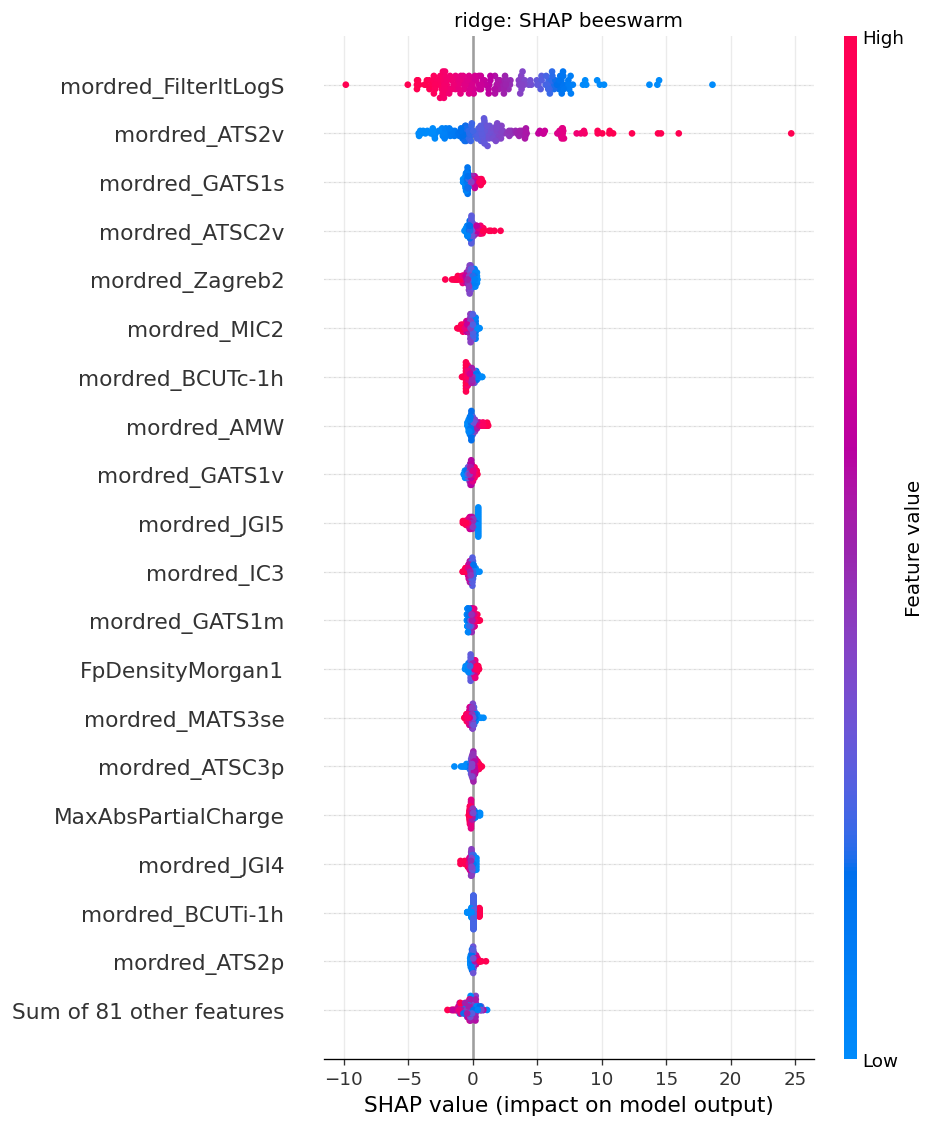

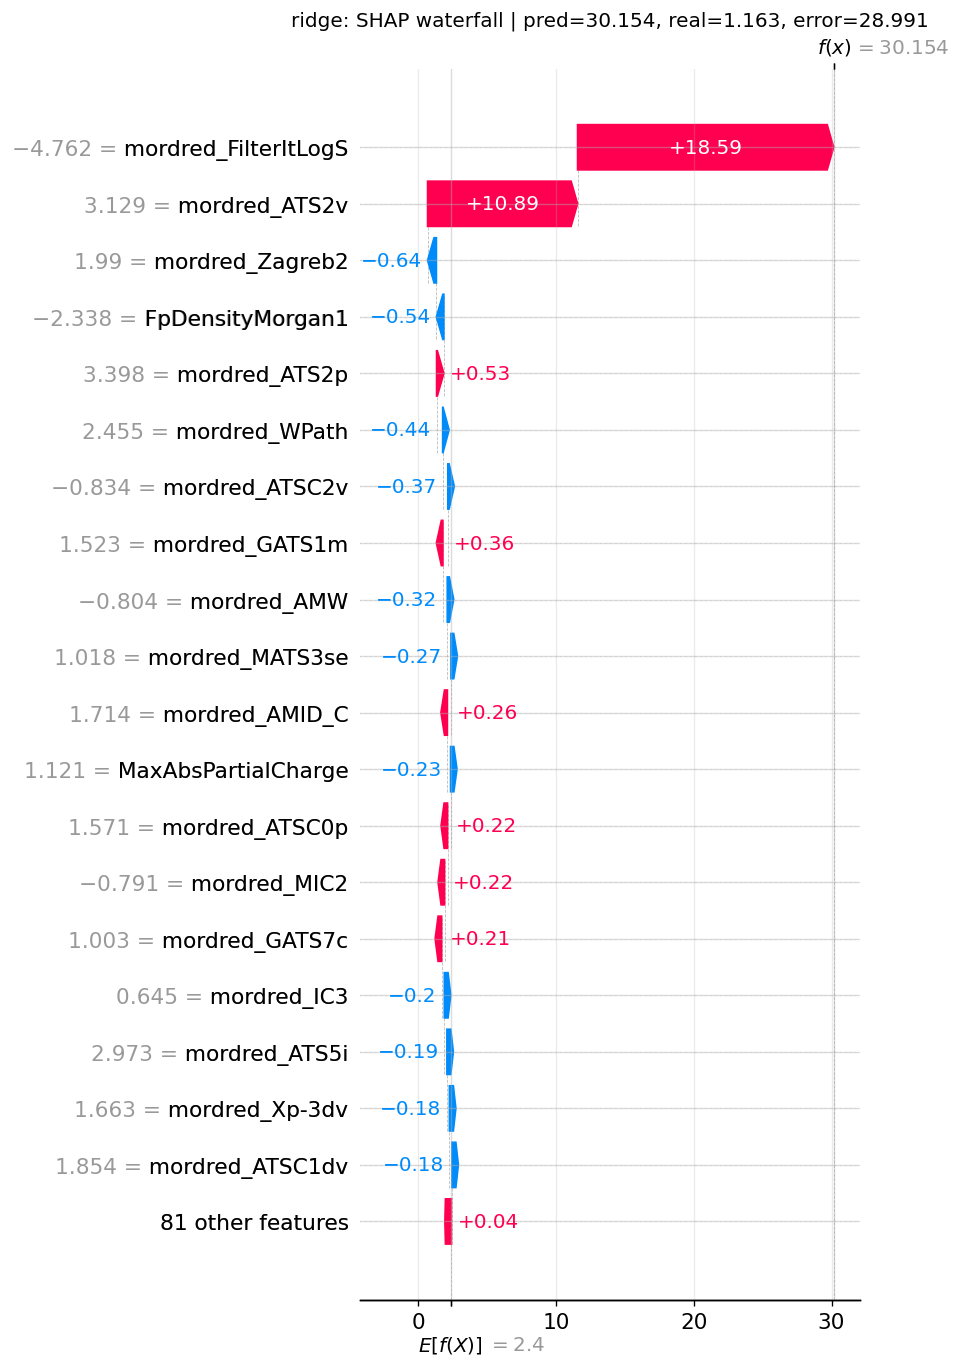

,model,feature,mean_abs_shap
27,ridge,mordred_FilterItLogS,3.734705
63,ridge,mordred_ATS2v,3.167466
52,ridge,mordred_GATS1s,0.358864
7,ridge,mordred_ATSC2v,0.323080
12,ridge,mordred_Zagreb2,0.321970
1,ridge,mordred_MIC2,0.287029
58,ridge,mordred_BCUTc-1h,0.259977
10,ridge,mordred_AMW,0.243329
8,ridge,mordred_GATS1v,0.222207
68,ridge,mordred_JGI5,0.207078


In [7]:
explain_idx = sample_indices(X_test.shape[0], EXPLAIN_SIZE, 1)
ridge_summary = explain_linear('ridge', models['ridge'], explain_idx)
ridge_summary.head(MAX_DISPLAY)


## Random Forest Interpretability

Source configuration: `model_random_forest.ipynb`.


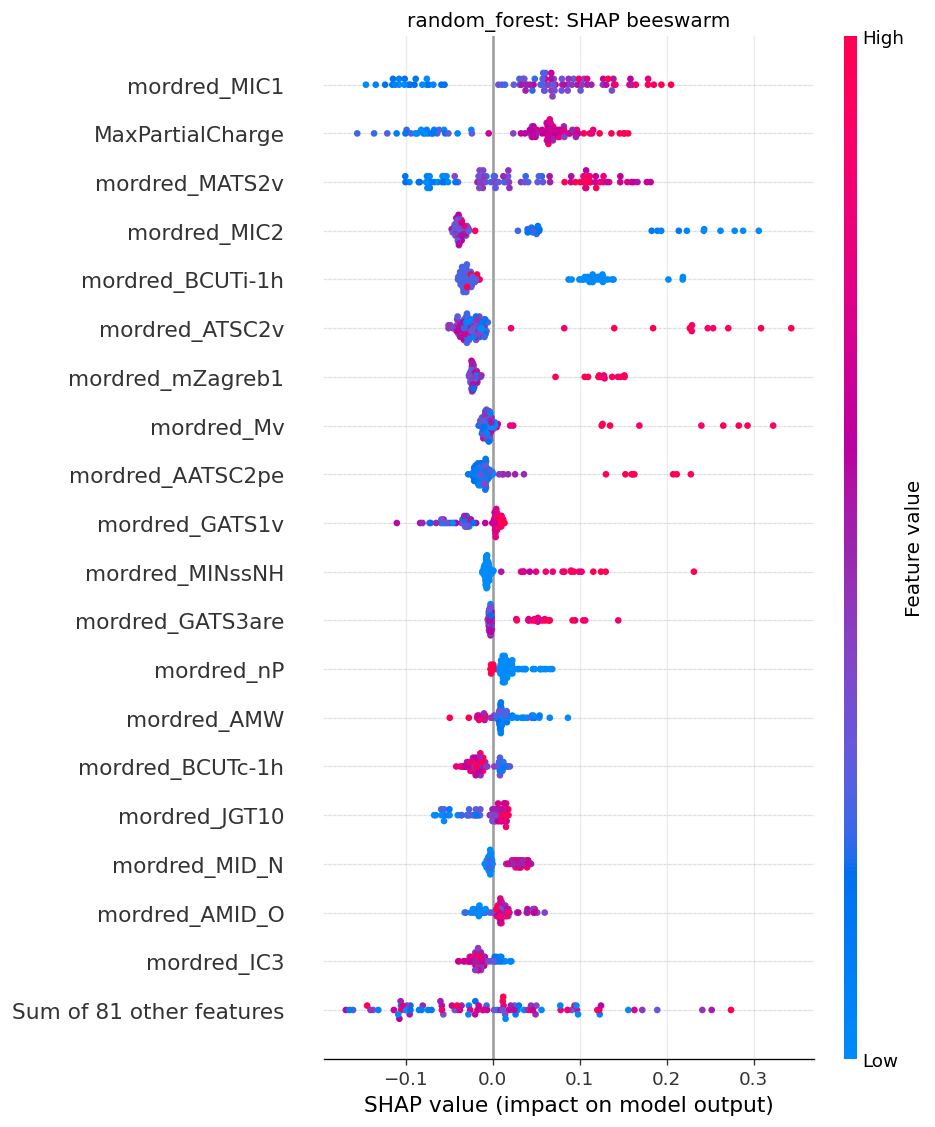

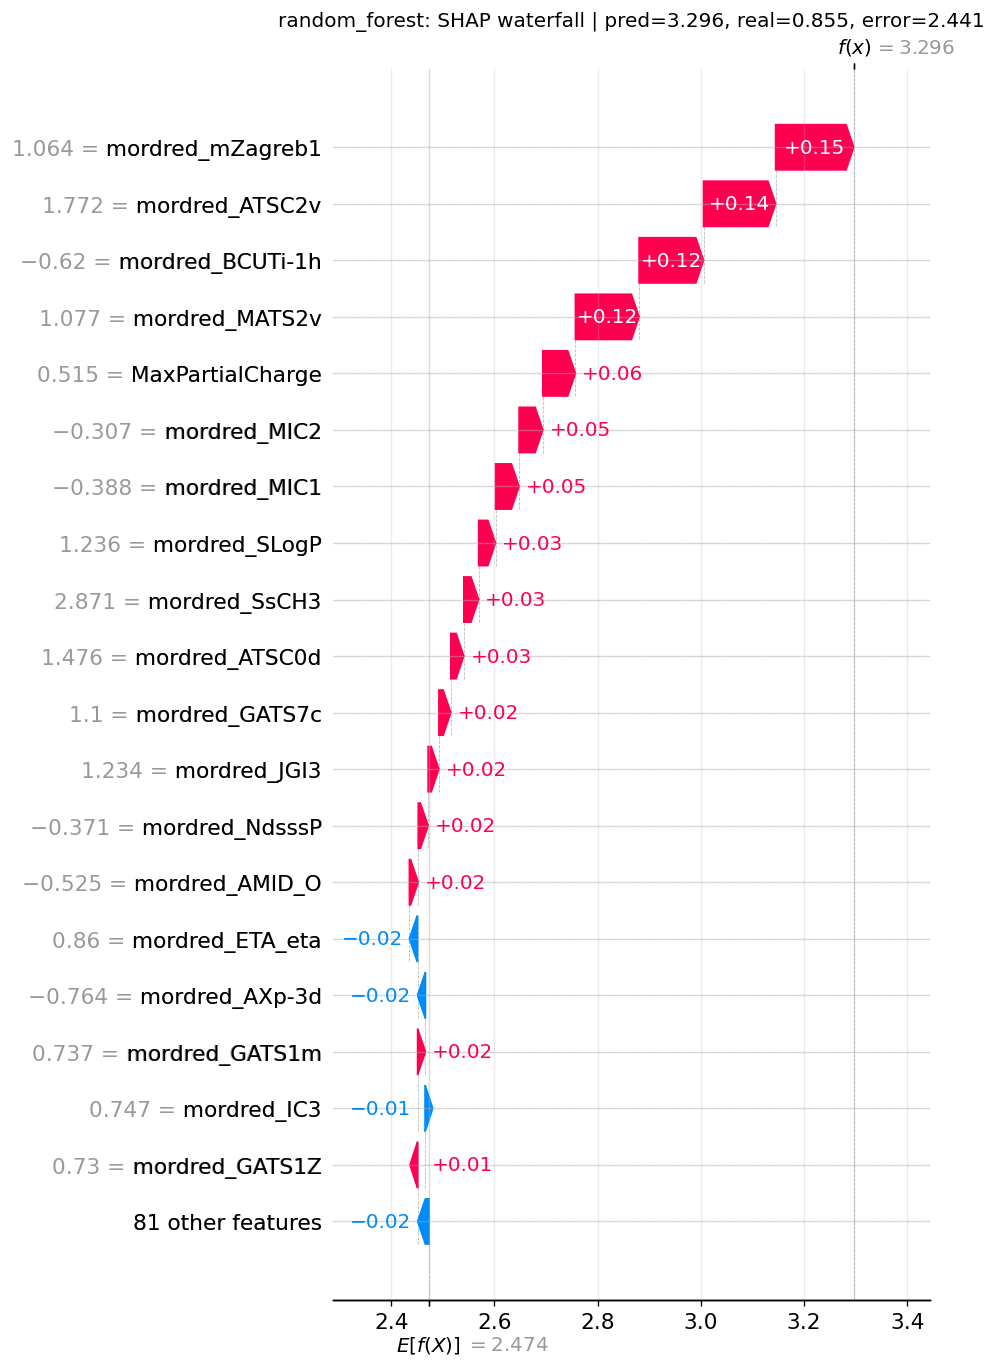

,model,feature,mean_abs_shap
2,random_forest,mordred_MIC1,0.089394
4,random_forest,MaxPartialCharge,0.075728
5,random_forest,mordred_MATS2v,0.069470
1,random_forest,mordred_MIC2,0.063636
3,random_forest,mordred_BCUTi-1h,0.062820
7,random_forest,mordred_ATSC2v,0.052540
6,random_forest,mordred_mZagreb1,0.039241
14,random_forest,mordred_Mv,0.027973
25,random_forest,mordred_AATSC2pe,0.027804
8,random_forest,mordred_GATS1v,0.023857


In [8]:
explain_idx = sample_indices(X_test.shape[0], min(90, EXPLAIN_SIZE), 2)
random_forest_summary = explain_tree('random_forest', models['random_forest'], explain_idx)
random_forest_summary.head(MAX_DISPLAY)


## SVM Interpretability

Source configuration: `model_svm.ipynb`.


/home/tommaso/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
/home/tommaso/miniconda3/envs/tox_prediction/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


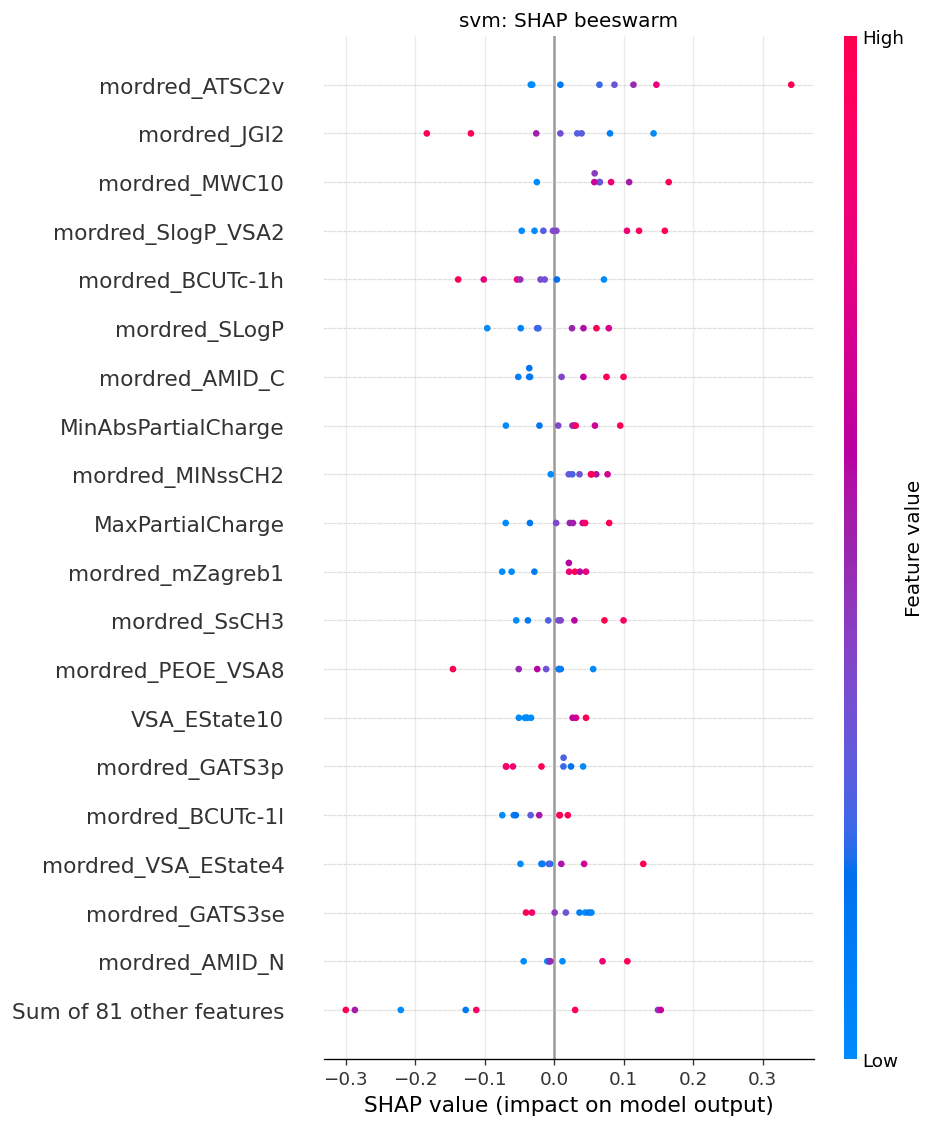

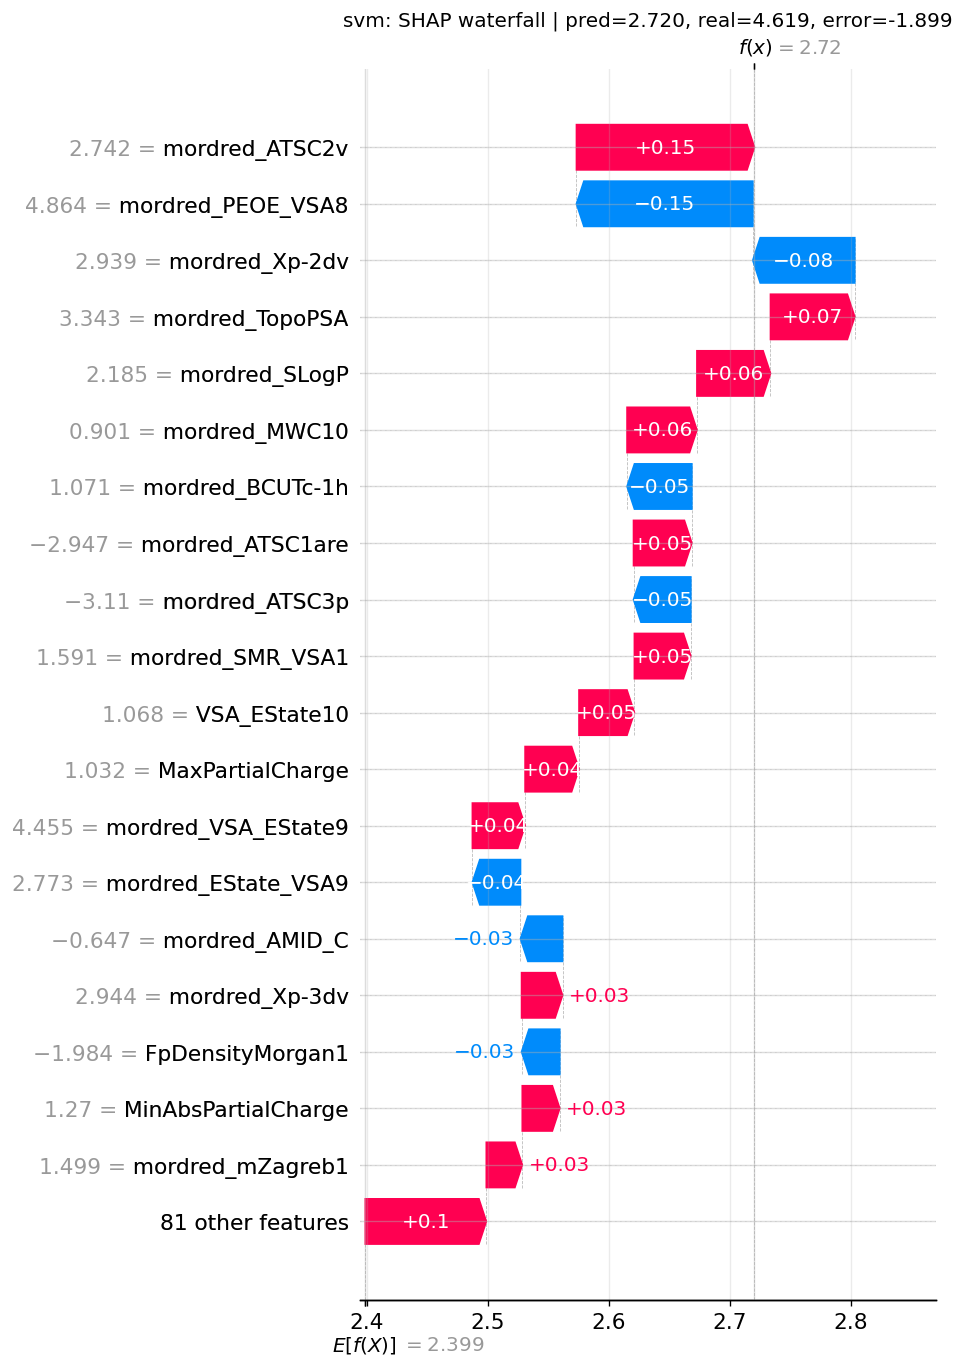

,model,feature,mean_abs_shap
7,svm,mordred_ATSC2v,0.103568
75,svm,mordred_JGI2,0.079247
16,svm,mordred_MWC10,0.078252
86,svm,mordred_SlogP_VSA2,0.060186
58,svm,mordred_BCUTc-1h,0.056360
13,svm,mordred_SLogP,0.049859
84,svm,mordred_AMID_C,0.048249
60,svm,MinAbsPartialCharge,0.042000
22,svm,mordred_MINssCH2,0.041543
4,svm,MaxPartialCharge,0.040211


In [9]:
explain_idx = sample_indices(X_test.shape[0], SVM_EXPLAIN_SIZE, 3)
svm_summary = explain_permutation('svm', models['svm'], explain_idx)
svm_summary.head(MAX_DISPLAY)


## XGBoost Interpretability

Source configuration: `model_xgboost.ipynb`.


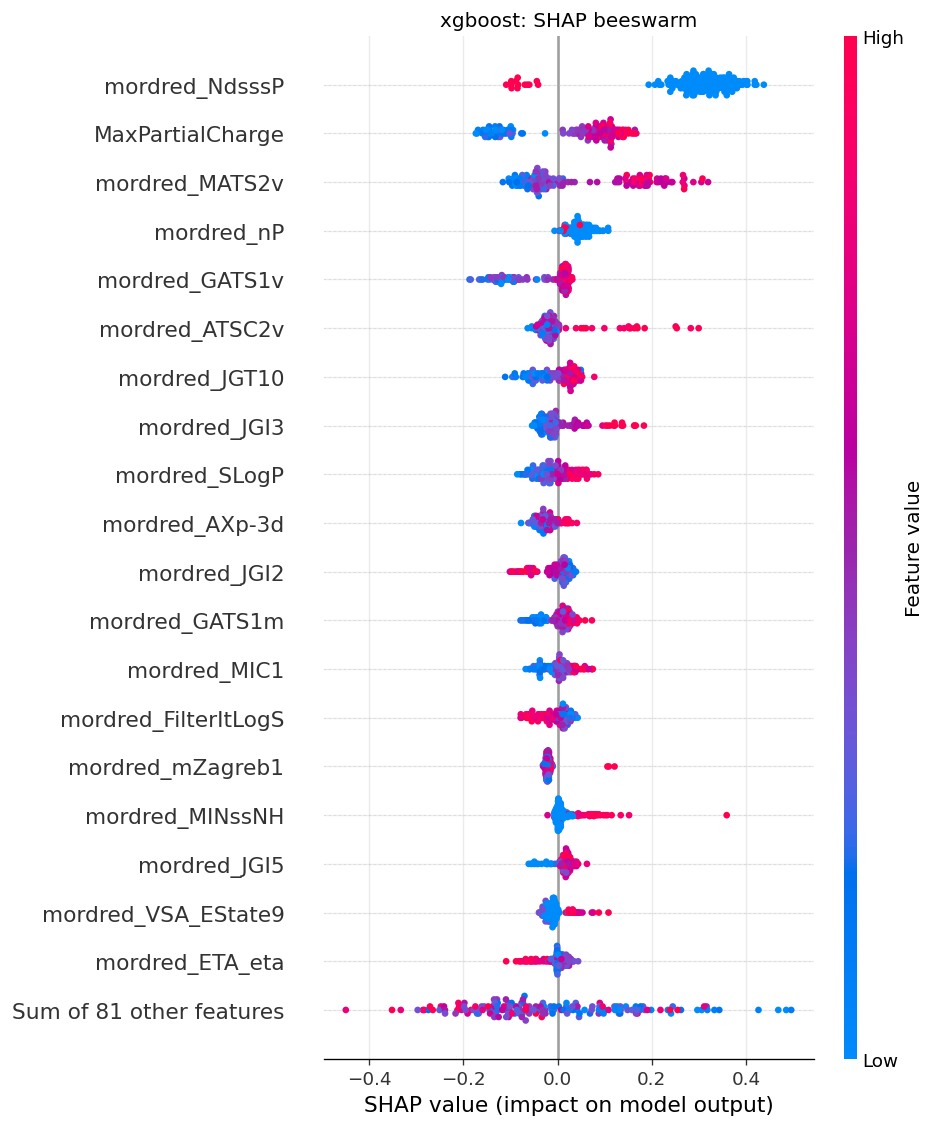

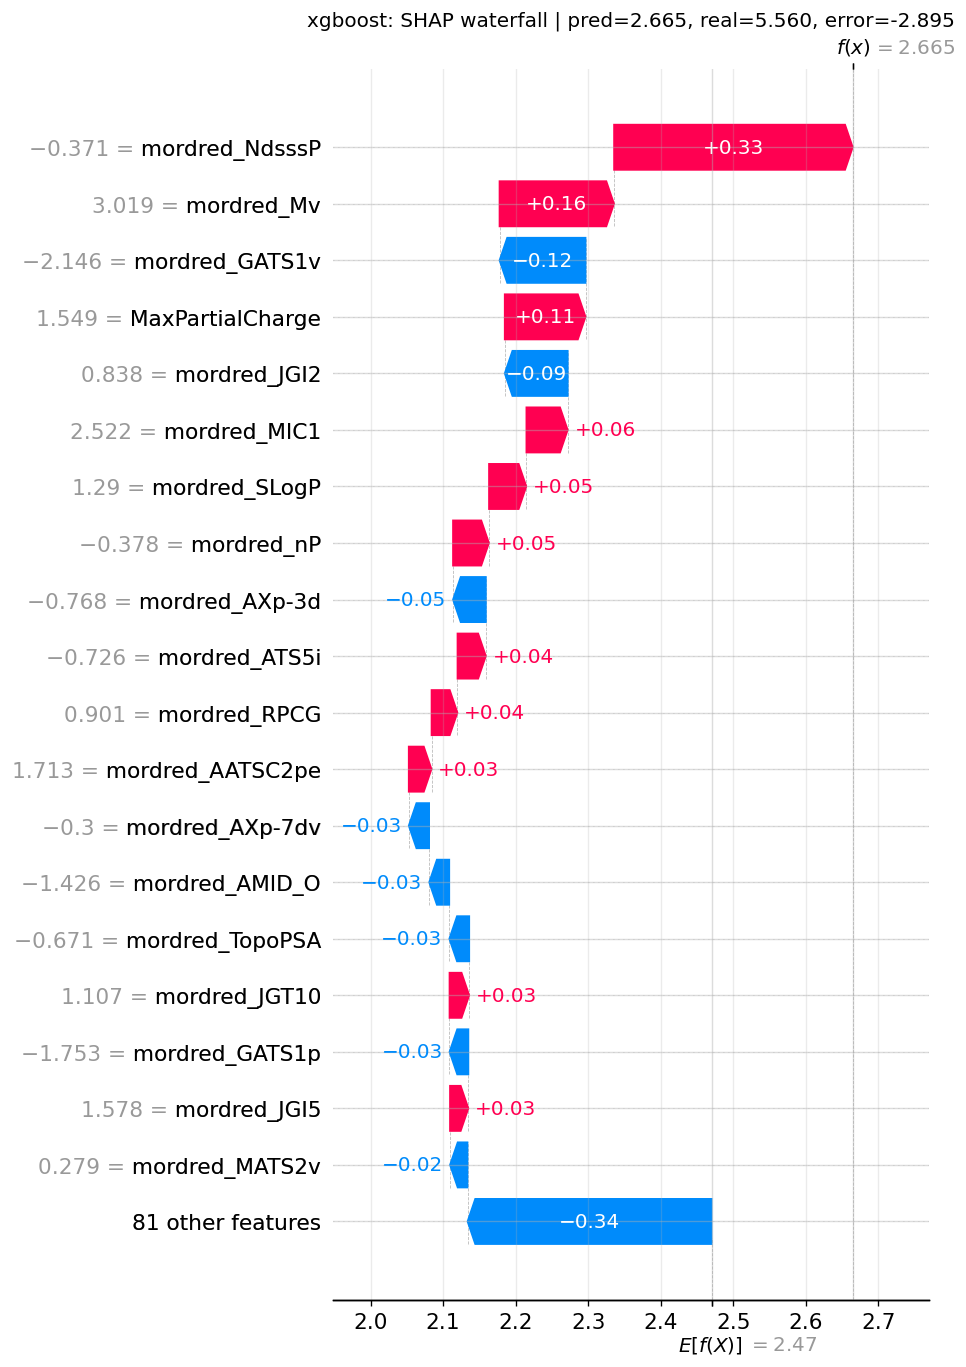

,model,feature,mean_abs_shap
0,xgboost,mordred_NdsssP,0.295647
4,xgboost,MaxPartialCharge,0.104269
5,xgboost,mordred_MATS2v,0.101180
33,xgboost,mordred_nP,0.048145
8,xgboost,mordred_GATS1v,0.047616
7,xgboost,mordred_ATSC2v,0.036681
28,xgboost,mordred_JGT10,0.033922
43,xgboost,mordred_JGI3,0.033235
13,xgboost,mordred_SLogP,0.030761
82,xgboost,mordred_AXp-3d,0.027994


In [10]:
explain_idx = sample_indices(X_test.shape[0], EXPLAIN_SIZE, 4)
xgboost_summary = explain_xgboost('xgboost', models['xgboost'], explain_idx)
xgboost_summary.head(MAX_DISPLAY)


## Weighted Ensemble Interpretability

Because the ensemble prediction is a weighted sum, its SHAP values are computed as the weighted sum of SHAP values from active components.


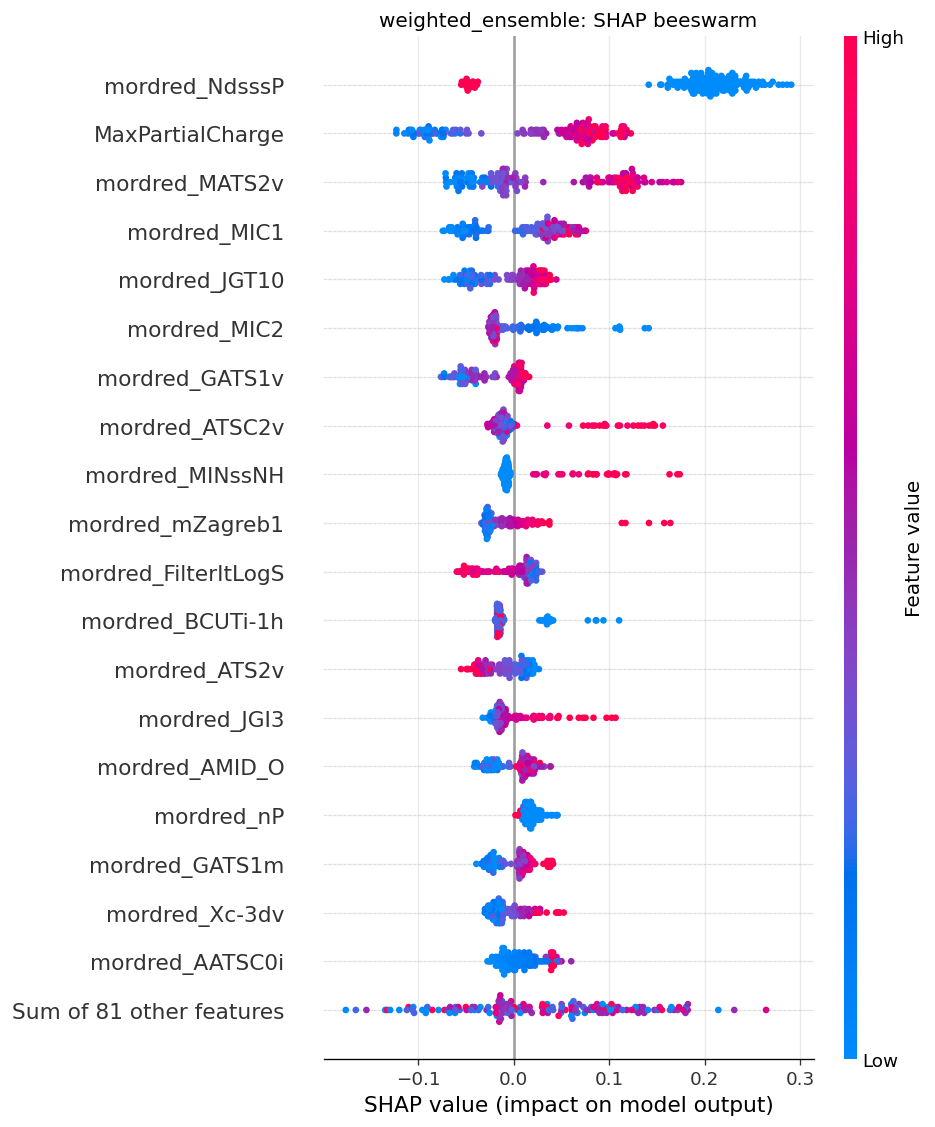

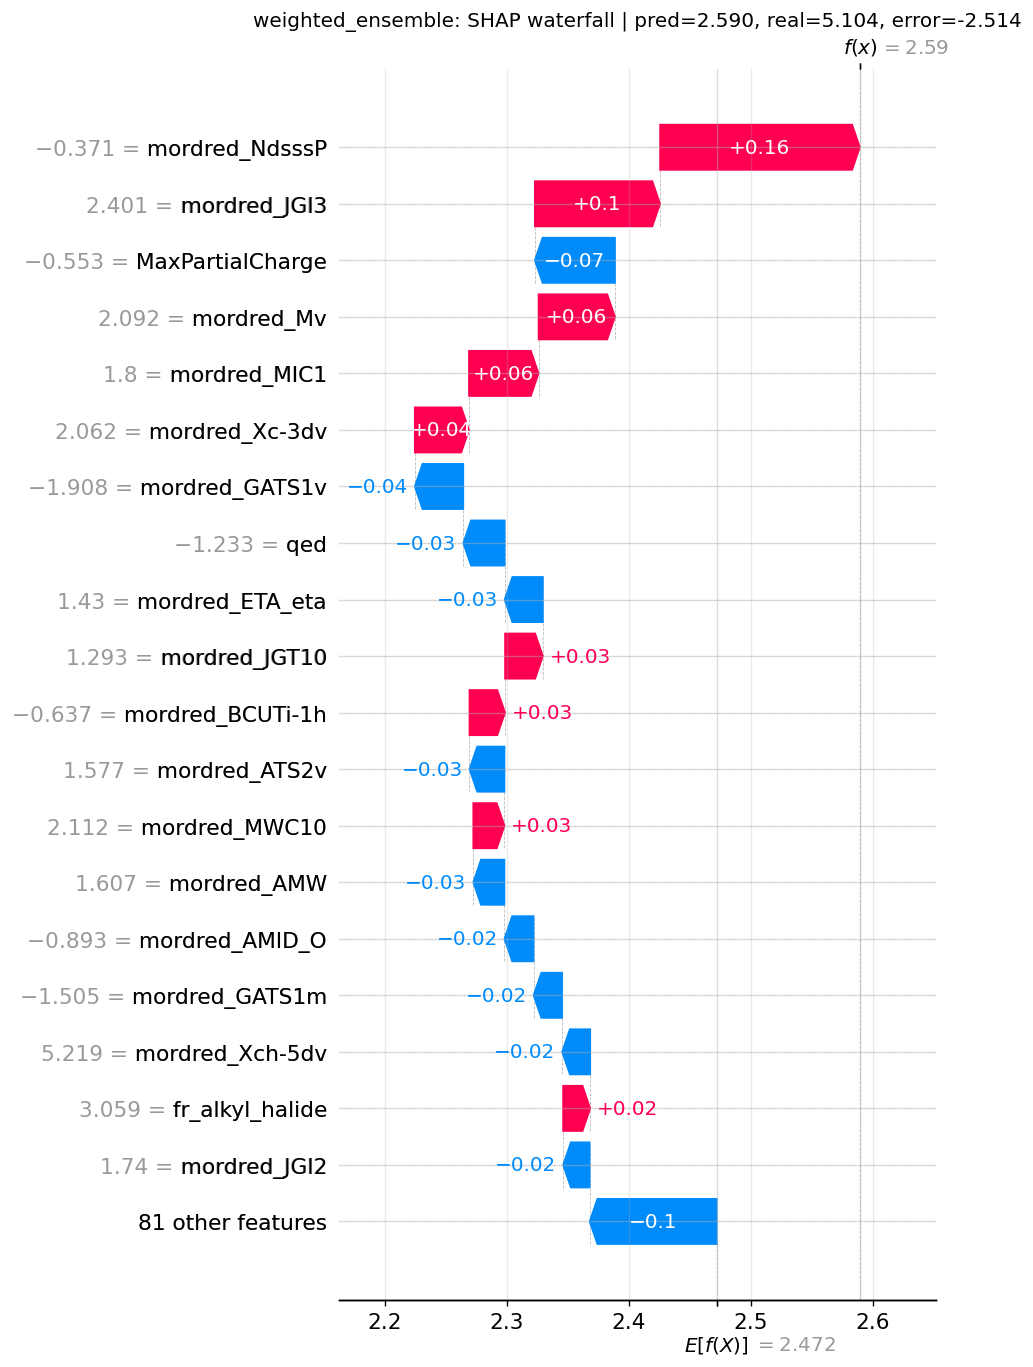

Max weighted-ensemble SHAP additivity error: 0.000001


,component,weight,explainer,component_mean_abs_shap
1,xgboost,0.634695,xgboost_pred_contribs,0.014781
0,extra_trees,0.365305,TreeExplainer,0.009766


In [11]:
def explain_weighted_ensemble(bundle):
    explain_idx = sample_indices(X_test.shape[0], EXPLAIN_SIZE, 5)
    X_explain_df = pd.DataFrame(X_test[explain_idx], columns=clean_feature_names)
    pred_explain = predictions['weighted_ensemble'][explain_idx]

    ensemble_values = np.zeros((X_explain_df.shape[0], X_explain_df.shape[1]), dtype=float)
    ensemble_base_values = np.zeros(X_explain_df.shape[0], dtype=float)
    component_rows = []

    for component_name, weight in bundle['weights'].items():
        weight = float(weight)
        if abs(weight) <= 1e-8:
            continue
        component_model = bundle['models'][component_name]
        if hasattr(component_model, 'get_booster'):
            component_explanation = xgboost_contrib_explanation(component_model, X_explain_df)
            values = np.asarray(component_explanation.values, dtype=float)
            base_values = np.asarray(component_explanation.base_values, dtype=float)
            explainer_name = 'xgboost_pred_contribs'
        else:
            try:
                explainer = shap.TreeExplainer(component_model, feature_names=list(clean_feature_names))
                values = np.asarray(explainer.shap_values(X_explain_df), dtype=float)
                if values.ndim == 3:
                    values = values[:, :, 0]
                expected = explainer.expected_value
                explainer_name = type(explainer).__name__
            except Exception as exc:
                warnings.warn(f'Falling back to permutation SHAP for {component_name}: {exc}')
                background = pd.DataFrame(X_train[:BACKGROUND_SIZE], columns=clean_feature_names)
                explainer = shap.Explainer(
                    component_model.predict,
                    shap.maskers.Independent(background),
                    algorithm='permutation',
                    feature_names=list(clean_feature_names),
                )
                component_explanation = explainer(X_explain_df, max_evals=2 * X_explain_df.shape[1] + 1, silent=True)
                values = np.asarray(component_explanation.values, dtype=float)
                expected = component_explanation.base_values
                explainer_name = type(explainer).__name__

            if np.ndim(expected) == 0:
                base_values = np.full(X_explain_df.shape[0], float(expected))
            else:
                expected_arr = np.asarray(expected, dtype=float).reshape(-1)
                base_values = np.full(X_explain_df.shape[0], float(expected_arr[0])) if expected_arr.size == 1 else expected_arr

        ensemble_values += weight * values
        ensemble_base_values += weight * base_values
        component_rows.append({
            'component': component_name,
            'weight': weight,
            'explainer': explainer_name,
            'component_mean_abs_shap': float(np.abs(values).mean()),
        })

    component_table = pd.DataFrame(component_rows).sort_values('weight', ascending=False)
    component_table.to_csv(TABLES_DIR / 'weighted_ensemble_components.csv', index=False)

    explanation = shap.Explanation(
        values=ensemble_values,
        base_values=ensemble_base_values,
        data=X_explain_df.to_numpy(),
        feature_names=list(clean_feature_names),
    )
    summary = save_shap_outputs('weighted_ensemble', explanation, X_explain_df, y_test[explain_idx], pred_explain)
    additivity_error = np.max(np.abs(ensemble_base_values + ensemble_values.sum(axis=1) - pred_explain))
    print(f'Max weighted-ensemble SHAP additivity error: {additivity_error:.6f}')
    return summary, component_table

weighted_ensemble_summary, weighted_ensemble_components = explain_weighted_ensemble(weighted_ensemble)
weighted_ensemble_components


## Cross-Model Comparison

Features that repeatedly appear in the top SHAP ranks are more stable interpretability signals than single-model artifacts.


In [12]:
summary_frames = []
for path in sorted(TABLES_DIR.glob('*_shap_summary.csv')):
    if path.name == 'all_models_top_shap_features.csv':
        continue
    summary_frames.append(pd.read_csv(path))

all_summaries = pd.concat(summary_frames, ignore_index=True)
all_summaries['rank_within_model'] = all_summaries.groupby('model')['mean_abs_shap'].rank(method='first', ascending=False)
top_features = all_summaries[all_summaries['rank_within_model'] <= MAX_DISPLAY].copy()
top_features.to_csv(TABLES_DIR / 'all_models_top_shap_features.csv', index=False)

overlap = (
    top_features.groupby('feature')
    .agg(
        n_models=('model', 'nunique'),
        models=('model', lambda values: ', '.join(sorted(set(values)))),
        mean_abs_shap_avg=('mean_abs_shap', 'mean'),
    )
    .sort_values(['n_models', 'mean_abs_shap_avg'], ascending=[False, False])
    .reset_index()
)
overlap.to_csv(TABLES_DIR / 'cross_model_feature_overlap.csv', index=False)
overlap.head(30)


,feature,n_models,models,mean_abs_shap_avg
0,mordred_ATSC2v,5,"random_forest, ridge, svm, weighted_ensemble, ...",0.108357
1,mordred_GATS1v,4,"random_forest, ridge, weighted_ensemble, xgboost",0.080102
2,MaxPartialCharge,4,"random_forest, svm, weighted_ensemble, xgboost",0.073701
3,mordred_GATS1m,4,"random_forest, ridge, weighted_ensemble, xgboost",0.062674
4,mordred_mZagreb1,4,"random_forest, svm, weighted_ensemble, xgboost",0.031067
5,mordred_FilterItLogS,3,"ridge, weighted_ensemble, xgboost",1.259944
6,mordred_ATS2v,3,"ridge, weighted_ensemble, xgboost",1.068443
7,mordred_MIC2,3,"random_forest, ridge, weighted_ensemble",0.125839
8,mordred_BCUTc-1h,3,"random_forest, ridge, svm",0.111171
9,mordred_MATS2v,3,"random_forest, weighted_ensemble, xgboost",0.078336


## Artifact Index


In [13]:
artifact_index = pd.DataFrame(
    [{'type': 'figure', 'path': str(path.relative_to(NOTEBOOK_DIR))} for path in sorted(FIGURES_DIR.glob('*.png'))]
    + [{'type': 'table', 'path': str(path.relative_to(NOTEBOOK_DIR))} for path in sorted(TABLES_DIR.glob('*.csv'))]
    + [{'type': 'model', 'path': str(path.relative_to(NOTEBOOK_DIR))} for path in sorted(INTERP_MODEL_DIR.glob('*.pkl'))]
)
artifact_index.to_csv(OUTCOME_DIR / 'artifact_index.csv', index=False)
artifact_index


,type,path
0,figure,outcome/figures/random_forest_shap_beeswarm.png
1,figure,outcome/figures/random_forest_shap_waterfall.png
2,figure,outcome/figures/ridge_shap_beeswarm.png
3,figure,outcome/figures/ridge_shap_waterfall.png
4,figure,outcome/figures/svm_shap_beeswarm.png
5,figure,outcome/figures/svm_shap_waterfall.png
6,figure,outcome/figures/weighted_ensemble_shap_beeswar...
7,figure,outcome/figures/weighted_ensemble_shap_waterfa...
8,figure,outcome/figures/xgboost_shap_beeswarm.png
9,figure,outcome/figures/xgboost_shap_waterfall.png
